## Imports and paths


In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────
MERGED_DIR  = Path("../data/merged")
FIGURES_DIR = Path("../outputs/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

WAVE_FILE = MERGED_DIR / "era5_waves_2014_2024.nc"
WIND_FILE = MERGED_DIR / "era5_wind_2014_2024.nc"

# ── Monsoon season definitions ─────────────────────────────────
# NE monsoon: October–March  (months 10,11,12,1,2,3)
# SW monsoon: May–September  (months 5,6,7,8,9)
# Transition: April, October (treated as NE here per Vietnamese convention)
NE_MONTHS = [10, 11, 12, 1, 2, 3]
SW_MONTHS = [5, 6, 7, 8, 9]

## Load data and compute spatial mean


In [2]:
# ── Load datasets ──────────────────────────────────────────────
ds_wave = xr.open_dataset(WAVE_FILE)
ds_wind = xr.open_dataset(WIND_FILE)

# ── Spatial mean over ocean points only ───────────────────────
# Wave variables are NaN over land — nanmean handles this automatically
hs   = ds_wave["swh"].mean(dim=["latitude", "longitude"], skipna=True)
mwp  = ds_wave["mwp"].mean(dim=["latitude", "longitude"], skipna=True)
mwd  = ds_wave["mwd"].mean(dim=["latitude", "longitude"], skipna=True)
u10  = ds_wind["u10"].mean(dim=["latitude", "longitude"])
v10  = ds_wind["v10"].mean(dim=["latitude", "longitude"])

# ── Convert to pandas Series for easier manipulation ──────────
hs_series  = hs.to_series()
mwp_series = mwp.to_series()
mwd_series = mwd.to_series()
u10_series = u10.to_series()
v10_series = v10.to_series()

print("Data loaded successfully")
print(f"  Hs  : {len(hs_series):,} hourly values  "
      f"({hs_series.index[0].date()} → {hs_series.index[-1].date()})")
print(f"  U10 : {len(u10_series):,} hourly values")

Data loaded successfully
  Hs  : 96,432 hourly values  (2014-01-01 → 2024-12-31)
  U10 : 96,432 hourly values


## Wave climate statistics table


In [3]:
def season_mask(index: pd.DatetimeIndex, months: list) -> pd.Series:
    """Return boolean mask for given months."""
    return index.month.isin(months)

# ── Build statistics ───────────────────────────────────────────
def hs_stats(series: pd.Series, label: str) -> dict:
    return {
        "Season"  : label,
        "Mean Hs (m)"  : round(series.mean(), 3),
        "P50 Hs (m)"   : round(series.quantile(0.50), 3),
        "P90 Hs (m)"   : round(series.quantile(0.90), 3),
        "P95 Hs (m)"   : round(series.quantile(0.95), 3),
        "Max Hs (m)"   : round(series.max(), 3),
        "N hours"      : len(series),
    }

ne_mask = season_mask(hs_series.index, NE_MONTHS)
sw_mask = season_mask(hs_series.index, SW_MONTHS)

stats_rows = [
    hs_stats(hs_series,           "Annual"),
    hs_stats(hs_series[ne_mask],  "NE Monsoon (Oct–Mar)"),
    hs_stats(hs_series[sw_mask],  "SW Monsoon (May–Sep)"),
]

stats_df = pd.DataFrame(stats_rows).set_index("Season")

print("=" * 60)
print("  Hs Wave Climate Statistics — Da Nang Bay (2014–2024)")
print("=" * 60)
print(stats_df.to_string())
print()

# Save to CSV
csv_path = FIGURES_DIR / "hs_statistics.csv"
stats_df.to_csv(csv_path)
print(f"Saved → {csv_path}")

  Hs Wave Climate Statistics — Da Nang Bay (2014–2024)
                      Mean Hs (m)  P50 Hs (m)  P90 Hs (m)  P95 Hs (m)  Max Hs (m)  N hours
Season                                                                                    
Annual                      1.030       0.843       1.995       2.335       5.742    96432
NE Monsoon (Oct–Mar)        1.412       1.242       2.311       2.622       5.742    48120
SW Monsoon (May–Sep)        0.599       0.537       0.889       1.058       4.914    40392

Saved → ../outputs/figures/hs_statistics.csv


## Hs time series with monsoon shading


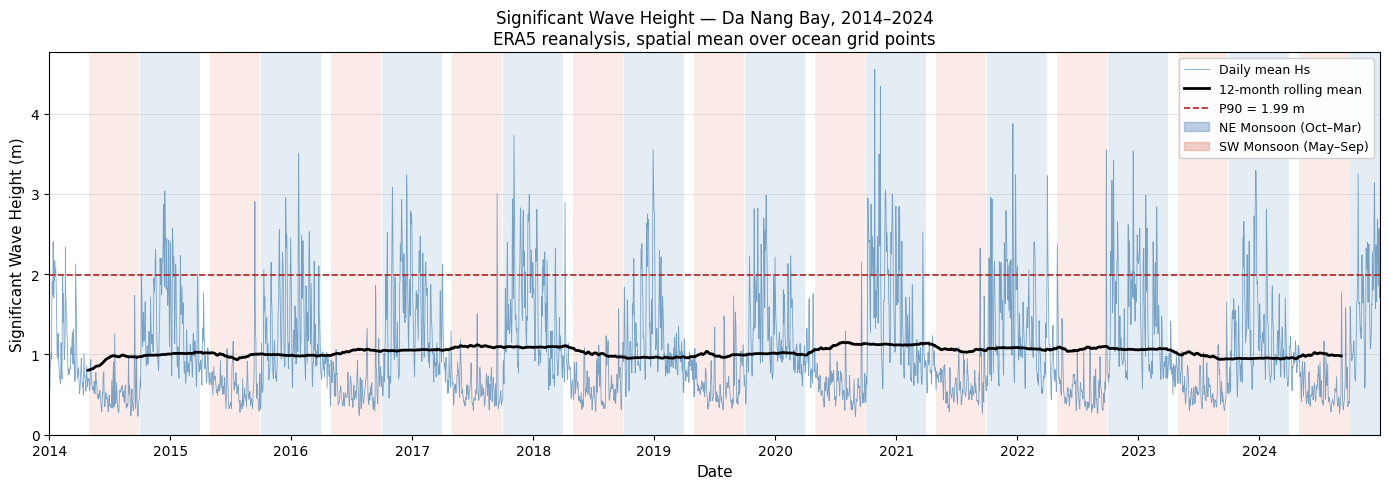

Saved → outputs/figures/hs_timeseries.png


In [4]:
# ── Resample to daily mean for plotting ───────────────────────
hs_daily  = hs_series.resample("D").mean()
hs_12m    = hs_daily.rolling(window=365, center=True, min_periods=300).mean()

# ── Build monsoon shading spans ───────────────────────────────
# We iterate over each year and shade NE / SW windows
years = range(2014, 2025)
ne_spans, sw_spans = [], []

for yr in years:
    # NE monsoon spans two calendar years: Oct(yr) → Mar(yr+1)
    ne_spans.append((pd.Timestamp(f"{yr}-10-01"),
                     pd.Timestamp(f"{yr+1}-03-31")))
    # SW monsoon within same year
    sw_spans.append((pd.Timestamp(f"{yr}-05-01"),
                     pd.Timestamp(f"{yr}-09-30")))

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

# Monsoon shading — draw before data so it sits behind
for start, end in ne_spans:
    ax.axvspan(start, end, alpha=0.12, color="#2166ac", lw=0)
for start, end in sw_spans:
    ax.axvspan(start, end, alpha=0.12, color="#d6604d", lw=0)

# Daily Hs
ax.plot(hs_daily.index, hs_daily.values,
        color="steelblue", lw=0.6, alpha=0.7, label="Daily mean Hs")

# 12-month rolling mean
ax.plot(hs_12m.index, hs_12m.values,
        color="black", lw=2.0, label="12-month rolling mean")

# P90 reference line
p90 = hs_series.quantile(0.90)
ax.axhline(p90, color="firebrick", ls="--", lw=1.2,
           label=f"P90 = {p90:.2f} m")

# Legend patches for monsoon shading
ne_patch = mpatches.Patch(color="#2166ac", alpha=0.3, label="NE Monsoon (Oct–Mar)")
sw_patch = mpatches.Patch(color="#d6604d", alpha=0.3, label="SW Monsoon (May–Sep)")

handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + [ne_patch, sw_patch],
          loc="upper right", fontsize=9, framealpha=0.9)

ax.set_xlim(hs_daily.index[0], hs_daily.index[-1])
ax.set_ylim(0, None)
ax.set_xlabel("Date", fontsize=11)
ax.set_ylabel("Significant Wave Height (m)", fontsize=11)
ax.set_title("Significant Wave Height — Da Nang Bay, 2014–2024\n"
             "ERA5 reanalysis, spatial mean over ocean grid points", fontsize=12)
ax.grid(axis="y", lw=0.5, alpha=0.5)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "hs_timeseries.png", dpi=300)
plt.show()
print("Saved → outputs/figures/hs_timeseries.png")

## Monthly Hs box plot


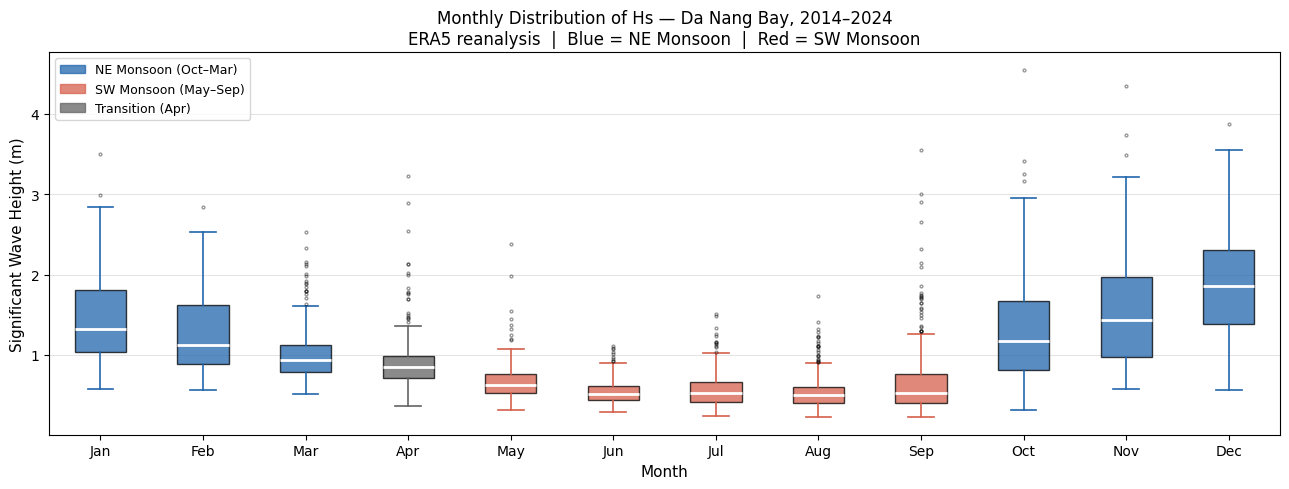

Saved → outputs/figures/hs_monthly_boxplot.png


In [5]:
# ── Resample hourly Hs to daily, attach month label ───────────
hs_df = hs_daily.to_frame(name="hs")
hs_df["month"] = hs_df.index.month

# Group into list of arrays for boxplot (Jan=1 ... Dec=12)
monthly_data = [hs_df.loc[hs_df["month"] == m, "hs"].dropna().values
                for m in range(1, 13)]

month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

# Colour each box by monsoon season
box_colours = []
for m in range(1, 13):
    if m in NE_MONTHS:
        box_colours.append("#2166ac")
    elif m in SW_MONTHS:
        box_colours.append("#d6604d")
    else:
        box_colours.append("#636363")   # transition months (Apr)

# ── Plot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

bp = ax.boxplot(monthly_data,
                patch_artist=True,
                medianprops=dict(color="white", lw=2),
                flierprops=dict(marker="o", markersize=2,
                                alpha=0.4, linestyle="none"),
                whiskerprops=dict(lw=1.2),
                capprops=dict(lw=1.2))

# Apply colours
for patch, colour in zip(bp["boxes"], box_colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.75)

for element in ["whiskers", "caps", "fliers"]:
    for item, colour in zip(
        bp[element],
        [c for c in box_colours for _ in range(2)]
    ):
        item.set_color(colour)

ax.set_xticklabels(month_labels, fontsize=10)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Significant Wave Height (m)", fontsize=11)
ax.set_title("Monthly Distribution of Hs — Da Nang Bay, 2014–2024\n"
             "ERA5 reanalysis  |  Blue = NE Monsoon  |  Red = SW Monsoon",
             fontsize=12)
ax.grid(axis="y", lw=0.5, alpha=0.5)

# Legend
ne_patch = mpatches.Patch(color="#2166ac", alpha=0.75, label="NE Monsoon (Oct–Mar)")
sw_patch = mpatches.Patch(color="#d6604d", alpha=0.75, label="SW Monsoon (May–Sep)")
tr_patch = mpatches.Patch(color="#636363", alpha=0.75, label="Transition (Apr)")
ax.legend(handles=[ne_patch, sw_patch, tr_patch],
          loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "hs_monthly_boxplot.png", dpi=300)
plt.show()
print("Saved → outputs/figures/hs_monthly_boxplot.png")

## Wind statistics table


In [6]:
# ── Compute wind speed and direction ──────────────────────────
wind_df = pd.DataFrame({
    "u10" : u10_series,
    "v10" : v10_series,
})
wind_df["speed"]     = np.sqrt(wind_df["u10"]**2 + wind_df["v10"]**2)
wind_df["direction"] = (270 - np.degrees(np.arctan2(wind_df["v10"],
                                                      wind_df["u10"]))) % 360
wind_df["month"]     = wind_df.index.month

# ── Monthly aggregation ────────────────────────────────────────
wind_monthly = (
    wind_df.groupby("month")
    .agg(
        mean_u10    = ("u10",       "mean"),
        mean_v10    = ("v10",       "mean"),
        mean_speed  = ("speed",     "mean"),
        p90_speed   = ("speed",     lambda x: x.quantile(0.90)),
        max_speed   = ("speed",     "max"),
    )
    .round(3)
)

wind_monthly.index = month_labels
wind_monthly.index.name = "Month"

# Rename columns for readability
wind_monthly.columns = [
    "Mean U10 (m/s)", "Mean V10 (m/s)",
    "Mean Speed (m/s)", "P90 Speed (m/s)", "Max Speed (m/s)"
]

print("=" * 70)
print("  Monthly Wind Statistics — Da Nang Bay (2014–2024)")
print("=" * 70)
print(wind_monthly.to_string())

# Save CSV
csv_path = FIGURES_DIR / "wind_statistics.csv"
wind_monthly.to_csv(csv_path)
print(f"\nSaved → {csv_path}")

  Monthly Wind Statistics — Da Nang Bay (2014–2024)
       Mean U10 (m/s)  Mean V10 (m/s)  Mean Speed (m/s)  P90 Speed (m/s)  Max Speed (m/s)
Month                                                                                    
Jan            -2.025          -1.464             3.155            5.201            8.434
Feb            -2.026          -0.570             3.111            4.749            7.658
Mar            -2.085           0.657             2.888            3.885            7.453
Apr            -1.716           0.973             2.797            3.840            7.959
May            -0.792           1.228             2.210            3.299            6.533
Jun             0.200           1.565             2.191            3.158            5.623
Jul             0.459           1.294             2.261            3.473            6.003
Aug             0.687           1.174             2.184            3.490            6.748
Sep            -0.167           0.215           